# COMP47950 Quantum Machine Learning Project

Replication of Selig et al. [20] variational classifier on 2–3 datasets, with classical baseline and real-device inference.

## 1. Datasets and train/test split

We use three datasets from [20] Table 1, loaded via scikit-learn:

| Dataset | Features | Classes | Train | Test | Notes |
|---------|----------|---------|-------|------|-------|
| Iris | 4 | 3 | 90 | 60 | No PCA |
| Wine | 13 | 3 | 108 | 70 | PCA (8 or 12 PCs) in preprocessing |
| Breast Cancer Wisconsin | 32 | 2 | 449 | 120 | PCA (12 or 16 PCs) in preprocessing |

**Split strategy:** Stratified train/test split matching [20] sizes, with `random_state=42` for reproducibility. Data is loaded on-the-fly from sklearn (no local caching).

In [44]:
from qml_project.datasets import (
    load_iris_splits,
    load_wine_splits,
    load_breast_cancer_splits,
)

In [45]:
X_iris_tr, X_iris_te, y_iris_tr, y_iris_te = load_iris_splits()
X_wine_tr, X_wine_te, y_wine_tr, y_wine_te = load_wine_splits()
X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = load_breast_cancer_splits()

print("Iris:", X_iris_tr.shape, X_iris_te.shape)
print("Wine:", X_wine_tr.shape, X_wine_te.shape)
print("Breast Cancer:", X_bc_tr.shape, X_bc_te.shape)

Iris: (90, 4) (60, 4)
Wine: (108, 13) (70, 13)
Breast Cancer: (449, 30) (120, 30)


In [46]:
import numpy as np

for name, y_tr, y_te in [
    ("Iris", y_iris_tr, y_iris_te),
    ("Wine", y_wine_tr, y_wine_te),
    ("Breast Cancer", y_bc_tr, y_bc_te),
]:
    tr_counts = np.bincount(y_tr)
    te_counts = np.bincount(y_te)
    print(f"{name}: train {dict(zip(range(len(tr_counts)), tr_counts))}, test {dict(zip(range(len(te_counts)), te_counts))}")

Iris: train {0: np.int64(30), 1: np.int64(30), 2: np.int64(30)}, test {0: np.int64(20), 1: np.int64(20), 2: np.int64(20)}
Wine: train {0: np.int64(36), 1: np.int64(43), 2: np.int64(29)}, test {0: np.int64(23), 1: np.int64(28), 2: np.int64(19)}
Breast Cancer: train {0: np.int64(167), 1: np.int64(282)}, test {0: np.int64(45), 1: np.int64(75)}


## 2. Preprocessing

All datasets are centred and scaled using `StandardScaler` (fit on training data only; transform applied to both train and test splits). For Wine (13 raw features) and Breast Cancer (30 raw features), we additionally apply PCA to reduce dimensionality before encoding.

### Why PCA? Feature selection as a quantum constraint

In classical ML, high-dimensional feature spaces are routine — wider data simply requires more compute. For quantum methods, however, the number of features directly constrains circuit design: each feature must be encoded into one or more qubit rotations, so the feature count determines the minimum circuit width (number of qubits). On current NISQ hardware, circuits are limited to roughly 10–100 qubits with significant noise, making it impractical to encode all 13 (Wine) or 30 (Breast Cancer) raw features directly.

This is a concrete instance of the **input problem** — one of the four key challenges in QML identified by Biamonte et al. [1]: *representing classical data in a way appropriate for quantum devices is hard*. PCA addresses this by projecting the data onto a lower-dimensional subspace (8 components for Wine, 12 for Breast Cancer, following [20]) that retains most of the variance while fitting within the qubit budget.

**Fair comparison:** The same PCA-reduced features are used for both the classical baselines and the QML pipeline, ensuring that any performance differences reflect the models themselves rather than differences in the input feature space.

### Angle mapping ([20] Eq. 2)

After scaling (and optional PCA), features destined for the quantum circuit are transformed via [20]'s angle mapping:

$$f(x) = \frac{(1-\alpha^2)\pi}{q} \cdot W$$

with $\alpha = 0.1$ and $q = 3$. Here $W$ is the scaled (and optionally PCA-reduced) feature vector. This maps values into a rotation-friendly range, avoiding saturation at the poles of the Bloch sphere. The classical baselines skip this step (no angle mapping) since it is specific to the quantum encoding.

In [47]:
from qml_project.preprocessing import preprocess

# Iris: no PCA
X_iris_tr_cl, X_iris_te_cl, _ = preprocess(X_iris_tr, X_iris_te, apply_angle_mapping_flag=False)
X_iris_tr_qml, X_iris_te_qml, _ = preprocess(X_iris_tr, X_iris_te, apply_angle_mapping_flag=True)

# Wine: PCA 8 components
X_wine_tr_cl, X_wine_te_cl, _ = preprocess(X_wine_tr, X_wine_te, n_components=8, apply_angle_mapping_flag=False)
X_wine_tr_qml, X_wine_te_qml, _ = preprocess(X_wine_tr, X_wine_te, n_components=8, apply_angle_mapping_flag=True)

# Breast Cancer: PCA 12 components
X_bc_tr_cl, X_bc_te_cl, _ = preprocess(X_bc_tr, X_bc_te, n_components=12, apply_angle_mapping_flag=False)
X_bc_tr_qml, X_bc_te_qml, _ = preprocess(X_bc_tr, X_bc_te, n_components=12, apply_angle_mapping_flag=True)

print("Classical (scale+PCA): Iris", X_iris_tr_cl.shape, "Wine", X_wine_tr_cl.shape, "BC", X_bc_tr_cl.shape)

Classical (scale+PCA): Iris (90, 4) Wine (108, 8) BC (449, 12)


## 3. Classical ML baseline

We train three classical classifiers (Logistic Regression, Random Forest, SVM) on the preprocessed data (scale + PCA where applicable). 

**Data prep:** Same as above; no angle mapping.

**Sampling:** Fixed train/test split from §1.

**Metrics:** Accuracy, F1 (macro), precision (macro), recall (macro), and confusion matrix.

In [48]:
from qml_project.baselines import evaluate_baselines
import pandas as pd

results_iris = evaluate_baselines(X_iris_tr_cl, X_iris_te_cl, y_iris_tr, y_iris_te)
results_wine = evaluate_baselines(X_wine_tr_cl, X_wine_te_cl, y_wine_tr, y_wine_te)
results_bc = evaluate_baselines(X_bc_tr_cl, X_bc_te_cl, y_bc_tr, y_bc_te)

In [49]:
def metrics_table(results: dict, dataset: str) -> pd.DataFrame:
    rows = []
    for model, r in results.items():
        rows.append({
            "Model": model,
            "Dataset": dataset,
            "Accuracy": f"{r['accuracy']:.4f}",
            "F1 (macro)": f"{r['f1_macro']:.4f}",
            "Precision (macro)": f"{r['precision_macro']:.4f}",
            "Recall (macro)": f"{r['recall_macro']:.4f}",
            "Train time (s)": f"{r['train_time_s']:.4f}",
            "Inference time (s)": f"{r['inference_time_s']:.6f}",
        })
    return pd.DataFrame(rows)

pd.concat([
    metrics_table(results_iris, "Iris"),
    metrics_table(results_wine, "Wine"),
    metrics_table(results_bc, "Breast Cancer"),
], ignore_index=True)

,Model,Dataset,Accuracy,F1 (macro),Precision (macro),Recall (macro),Train time (s),Inference time (s)
0,Logistic Regression,Iris,0.9333,0.9332,0.9360,0.9333,0.0056,0.000284
1,Random Forest,Iris,0.9167,0.9162,0.9224,0.9167,0.1035,0.002679
2,SVM,Iris,0.9500,0.9500,0.9507,0.9500,0.0009,0.000210
3,Logistic Regression,Wine,0.9571,0.9589,0.9610,0.9586,0.0052,0.000210
4,Random Forest,Wine,0.9000,0.9045,0.9062,0.9033,0.1045,0.002934
5,SVM,Wine,0.9857,0.9851,0.9885,0.9825,0.0008,0.000206
6,Logistic Regression,Breast Cancer,0.9667,0.9730,0.9863,0.9600,0.0037,0.000210
7,Random Forest,Breast Cancer,0.9333,0.9467,0.9467,0.9467,0.1411,0.003597
8,SVM,Breast Cancer,0.9750,0.9799,0.9865,0.9733,0.0015,0.000391


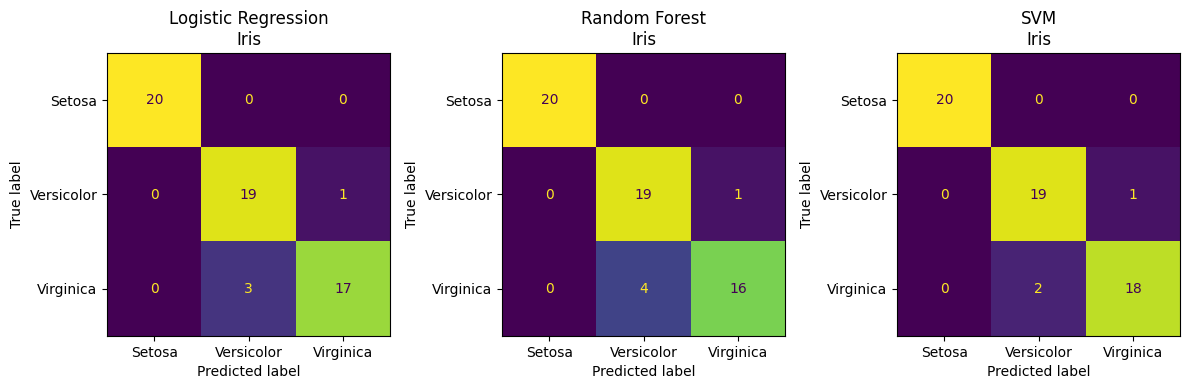

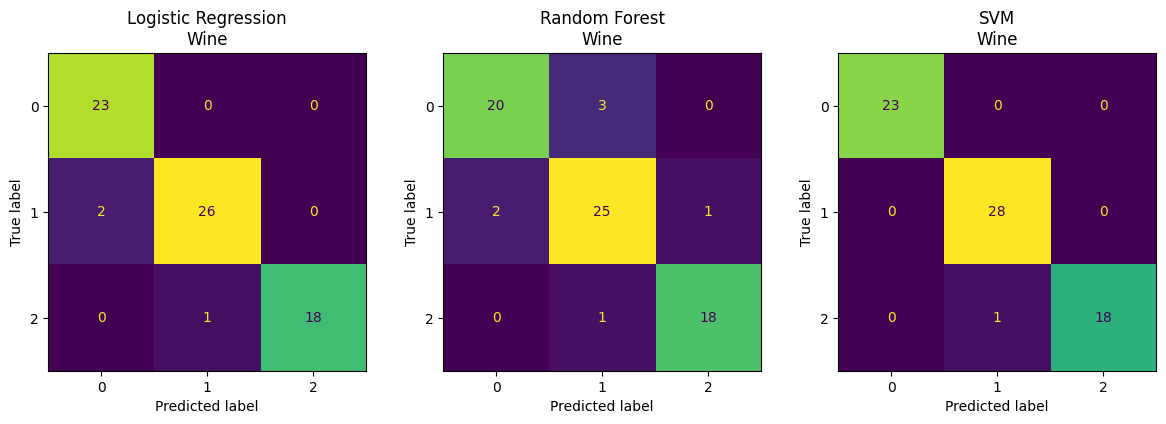

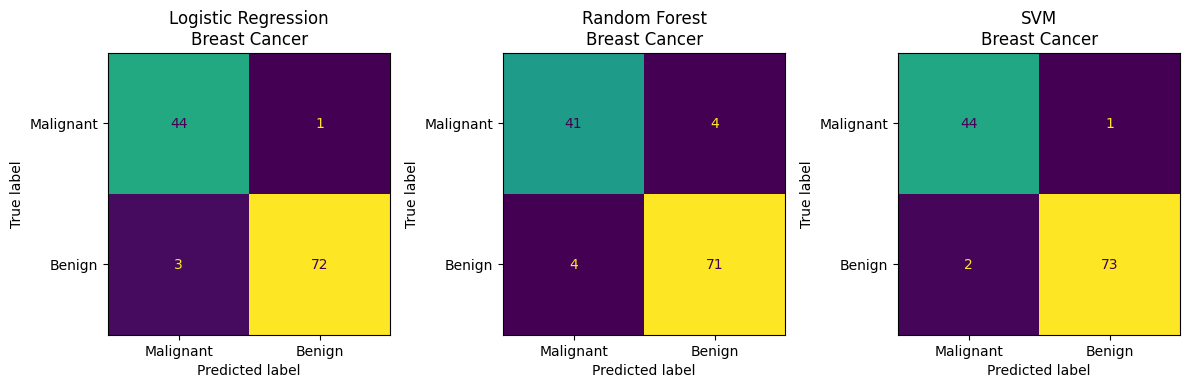

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrices(results: dict, dataset: str, class_names: list[str] | None = None):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, (model, r) in zip(axes, results.items()):
        disp = ConfusionMatrixDisplay(
            confusion_matrix=r["confusion_matrix"],
            display_labels=class_names or [str(i) for i in range(r["n_classes"])],
        )
        disp.plot(ax=ax, colorbar=False)
        ax.set_title(f"{model}\n{dataset}")
    plt.tight_layout()
    plt.show()

plot_confusion_matrices(results_iris, "Iris", ["Setosa", "Versicolor", "Virginica"])
plot_confusion_matrices(results_wine, "Wine")
plot_confusion_matrices(results_bc, "Breast Cancer", ["Malignant", "Benign"])

### QML-challenge commentary

The challenges below are organised around the **Four Key Problems** of QML identified by Biamonte et al. [1]: (1) the *input problem* — how to represent classical data quantumly; (2) the *output problem* — how to extract predictions from measurements; (3) the *costing problem* — circuit size, gate count, and depth; and (4) the *benchmarking problem* — what "better" means when comparing quantum and classical models.

#### Per-dataset challenges

**Iris (4 features, 3 classes, well-separated):**
- *Input problem:* All four features fit naturally into four qubit rotations — no dimensionality reduction needed. The angle-mapping range is narrow, however, so the circuit may not exploit the full Bloch sphere.
- *Costing problem:* With only 4 qubits the circuit is shallow and fast, but the limited expressivity may cause the variational model to underfit relative to classical baselines.
- *Benchmarking problem:* Classical models already achieve >91 % accuracy here; any QML improvement must be weighed against its circuit overhead.

**Wine (8 PCs after PCA, 3 classes, moderate overlap):**
- *Input problem:* The raw 13 features are reduced to 8 principal components to fit the qubit budget — a direct instance of feature selection as a quantum constraint (see Section 2). Information lost in PCA truncation may hurt QML disproportionately.
- *Costing problem:* Encoding 8 features into angle rotations on 8 qubits keeps depth manageable, but class overlap may require deeper entangling layers that push against NISQ noise limits.
- *Benchmarking problem:* SVM already reaches ~98 % accuracy on this dataset, setting a high classical bar.

**Breast Cancer (12 PCs after PCA, 2 classes, moderate class imbalance):**
- *Input problem:* 30 raw features are compressed to 12 PCs — a more aggressive reduction. The binary classification simplifies the output mapping but the 12-qubit circuit is the widest in this study.
- *Costing problem:* Deeper circuits could model complex decision boundaries better, but they are exponentially more sensitive to NISQ-era noise [20]. This dataset directly tests the depth-vs-noise trade-off.
- *Output problem:* Class imbalance means measurement statistics may be skewed; evaluation must account for this via macro-averaged metrics rather than raw accuracy alone.

#### QML model volatility

QML models are known to be "quite volatile and sensitive to starting conditions" (lecture). Small differences in random parameter initialisation, measurement shot noise, and optimiser trajectories can lead to large variance in final performance. This motivates training **multiple model instances with different random seeds** in Phase 2 and reporting mean ± standard deviation, rather than a single point estimate.

#### Speed and cost as comparison dimensions

The classical baselines above now include **training time** and **inference time** (wall-clock, measured with `time.perf_counter()`). These provide a concrete cost reference for the three-way comparison in Phase 3: classical baselines set the floor, simulated QML will add circuit-compilation and shot-sampling overhead, and real-device execution will additionally incur queue wait times and transpilation cost. Tracking these metrics from the start enables a fair, multi-dimensional comparison across *performance, speed, cost, and interpretability*.

## 4. QML model design

This section describes the variational quantum classifier architecture that replicates the circuit design from Selig et al. [20] Section 3. The circuit is parameterised: some rotation angles are **features** (data-dependent, fixed at inference) and others are **trainable weights** (optimised during training).

### 4.1 Basic block

Each qubit in each layer receives a **basic block** of three gates:

$$R_X(\pi/2) \;\rightarrow\; R_Z(\phi) \;\rightarrow\; R_X(\pi/2)$$

where $\phi$ is either:
- A **feature value** $\omega_i$ (angle-mapped, from Section 2), or
- A **trainable parameter** $\theta_j$ initialised uniformly in $[-\pi, \pi]$.

The two $R_X(\pi/2)$ gates rotate the qubit into the equatorial plane of the Bloch sphere, so the $R_Z$ rotation effectively encodes the feature/parameter as a phase shift. This is equivalent to a general single-qubit rotation with one degree of freedom — expressive enough for encoding while keeping circuit depth low.

### 4.2 Layer structure

A **layer** consists of:
1. One basic block per qubit (all qubits in parallel).
2. A set of **CZ (controlled-Z) entangling gates** between selected qubit pairs.

Layers alternate between **feature layers** (where the $R_Z$ slots are filled with input features) and **parameter layers** (where all $R_Z$ slots are trainable). When a feature layer has more qubit slots than remaining features, the extra slots become trainable parameters. This ensures every feature is used at least once while padding for expressivity.

| Layer type | $R_Z$ angles | Purpose |
|------------|-------------|---------|
| Feature | Input features $\omega_i$ (+ padding $\theta_j$) | Encode classical data |
| Parameter | Trainable weights $\theta_j$ | Learn decision boundaries |

### 4.3 CZ entanglement

After each layer's basic blocks, **CZ gates** create entanglement between qubits. [20] explores several strategies:

- **Linear:** Adjacent pairs $(0,1), (1,2), \ldots$ — simple, low depth.
- **All-to-all:** Every unique pair — maximum entanglement, higher depth.
- **Random:** 1–3 randomly chosen pairs per layer — explores the variance of CZ configurations noted in [20] Section 6.

CZ is a two-qubit gate that introduces a phase flip conditioned on both qubits being in $|1\rangle$. It generates entanglement without adding parametric complexity, and [20] found that shallow circuits with limited CZ gates can still achieve competitive accuracy while being more robust to noise.

### 4.4 Output mapping

After all layers, every qubit is measured in the **Z-basis**, yielding a bitstring of length $n$ (e.g. `0110` for 4 qubits). The $2^n$ possible bitstrings are partitioned into $K$ equal-size bins, one per class:

$$\text{class}(b) = \left\lfloor \frac{b}{\lfloor 2^n / K \rfloor} \right\rfloor, \quad b \in \{0, 1, \ldots, 2^n - 1\}$$

If $2^n$ is not divisible by $K$, the leftover bitstrings are discarded. The **class probability** $P_k$ is the fraction of measured shots that fall into bin $k$ (normalised over valid bitstrings).

This is a concrete instance of the **output problem** [1]: extracting a classical prediction from quantum measurements requires choosing a mapping scheme (here, equal-range binning) and accepting that measurement noise directly affects the class probability estimates.

### 4.5 Loss function

The loss function is the **softmax negative log-likelihood** from [20] Eq. 3:

$$\mathcal{L}_\theta(x, y) = -\log \frac{e^{P_y}}{\sum_{k=1}^{K} e^{P_k}}$$

where $P_k$ are the class probabilities and $y$ is the true label. Training minimises the mean loss over the training set. The softmax ensures the probabilities are well-behaved even when some class bins have zero or near-zero counts.

In [51]:
from qml_project.circuit import build_circuit, counts_to_class_probs, softmax_nll_loss

# Build a circuit for Iris: 4 features, 4 qubits, 3 classes, linear CZ
vc_iris = build_circuit(n_qubits=4, n_features=4, n_classes=3, cz_strategy="linear")

print(f"Iris circuit: {vc_iris.n_qubits} qubits, {vc_iris.n_layers} layers "
      f"({vc_iris.n_features} features + {vc_iris.n_trainable} trainable params)")
print(f"Layer types: {vc_iris.layer_types}")
print(f"Circuit depth: {vc_iris.circuit.depth()}")
print(f"Gate counts: {dict(vc_iris.circuit.count_ops())}")

Iris circuit: 4 qubits, 4 layers (4 features + 12 trainable params)
Layer types: ['feature', 'param', 'feature', 'param']
Circuit depth: 25
Gate counts: {'rx': 32, 'rz': 16, 'cz': 12, 'barrier': 4, 'measure': 4}


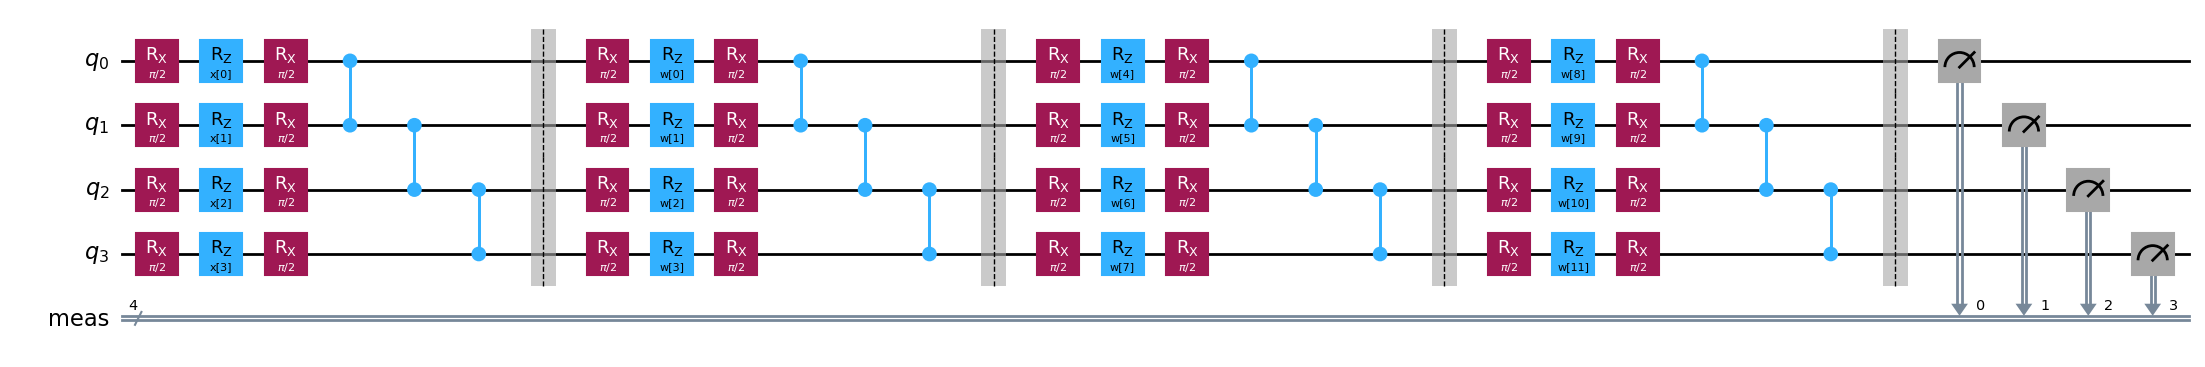

In [52]:
# Visualise the Iris circuit
vc_iris.circuit.draw(output="mpl", style="iqp", fold=40)

**Figure 1: Iris variational classifier circuit.** Four qubits encode four features across alternating feature and parameter layers, with linear CZ entanglement between each layer. Feature rotations (`x[i]`) carry the angle-mapped input data; weight rotations (`w[j]`) are optimised during training.

In [53]:
# Demonstrate the output mapping for Iris (4 qubits, 3 classes)
# 2^4 = 16 bitstrings, split into 3 bins of size 5 (1 leftover)
print("Bitstring → class mapping (4 qubits, 3 classes):")
print(f"  16 bitstrings ÷ 3 classes = 5 per bin, 1 discarded\n")

for bs_int, cls in vc_iris.class_map.items():
    label = f"class {cls}" if cls >= 0 else "discarded"
    print(f"  |{bs_int:04b}⟩ (decimal {bs_int:2d}) → {label}")

Bitstring → class mapping (4 qubits, 3 classes):
  16 bitstrings ÷ 3 classes = 5 per bin, 1 discarded

  |0000⟩ (decimal  0) → class 0
  |0001⟩ (decimal  1) → class 0
  |0010⟩ (decimal  2) → class 0
  |0011⟩ (decimal  3) → class 0
  |0100⟩ (decimal  4) → class 0
  |0101⟩ (decimal  5) → class 1
  |0110⟩ (decimal  6) → class 1
  |0111⟩ (decimal  7) → class 1
  |1000⟩ (decimal  8) → class 1
  |1001⟩ (decimal  9) → class 1
  |1010⟩ (decimal 10) → class 2
  |1011⟩ (decimal 11) → class 2
  |1100⟩ (decimal 12) → class 2
  |1101⟩ (decimal 13) → class 2
  |1110⟩ (decimal 14) → class 2
  |1111⟩ (decimal 15) → discarded


In [54]:
# Quick sanity check: run the circuit on one Iris sample with random weights
from qiskit.primitives import StatevectorSampler
from qiskit.primitives.containers.bindings_array import BindingsArray
from qiskit.primitives.containers.sampler_pub import SamplerPub

rng = np.random.default_rng(42)
theta_init = rng.uniform(-np.pi, np.pi, vc_iris.n_trainable)

# Bind one test sample's features + random weights
sample = X_iris_te_qml[0:1]  # shape (1, 4)
bound_values = vc_iris.bind(sample, theta_init)

sampler = StatevectorSampler()
ba = BindingsArray({tuple(vc_iris.circuit.parameters): bound_values})
pub = SamplerPub(circuit=vc_iris.circuit, parameter_values=ba, shots=500)
job = sampler.run([pub])  # type: ignore[arg-type]
result = job.result()
counts = result[0].data.meas.get_counts(0)  # type: ignore[attr-defined]

probs = counts_to_class_probs(counts, vc_iris.n_qubits, vc_iris.n_classes,
                               class_map=vc_iris.class_map)
loss = softmax_nll_loss(probs, int(y_iris_te[0]))

print(f"Sample 0 (true class {y_iris_te[0]}):")
print(f"  Measurement counts: {dict(sorted(counts.items()))}")
print(f"  Class probabilities: {probs}")
print(f"  Predicted class: {np.argmax(probs)}")
print(f"  Softmax NLL loss: {loss:.4f}")

Sample 0 (true class 0):
  Measurement counts: {'0000': 5, '0010': 225, '0011': 58, '0101': 48, '0110': 3, '1001': 12, '1010': 1, '1011': 6, '1100': 37, '1101': 39, '1110': 52, '1111': 14}
  Class probabilities: [0.59259259 0.12962963 0.27777778]
  Predicted class: 0
  Softmax NLL loss: 0.8584


The random-weight prediction above is essentially a coin flip — the circuit has not been trained yet. The loss value will decrease as the optimiser (Phase 2 training, next section) adjusts the trainable parameters $w_j$ to minimise $\mathcal{L}$ over the training set.

### 4.6 Circuits for all three datasets

We construct one circuit per dataset, matching each dataset's feature count to the number of qubits (as recommended by [20]: $n_\text{qubits} \leq n_\text{features}$). The table below summarises the circuit configurations.

In [55]:
# Build circuits for all three datasets
circuit_configs = {
    "Iris":          {"n_qubits": 4,  "n_features": 4,  "n_classes": 3},
    "Wine":          {"n_qubits": 8,  "n_features": 8,  "n_classes": 3},
    "Breast Cancer": {"n_qubits": 12, "n_features": 12, "n_classes": 2},
}

circuits = {}
for name, cfg in circuit_configs.items():
    circuits[name] = build_circuit(**cfg, cz_strategy="linear")

# Summary table
rows = []
for name, vc in circuits.items():
    ops = vc.circuit.count_ops()
    rows.append({
        "Dataset": name,
        "Qubits": vc.n_qubits,
        "Features": vc.n_features,
        "Classes": vc.n_classes,
        "Layers": vc.n_layers,
        "Trainable params": vc.n_trainable,
        "Circuit depth": vc.circuit.depth(),
        "RX gates": ops.get("rx", 0),
        "RZ gates": ops.get("rz", 0),
        "CZ gates": ops.get("cz", 0),
        "Discarded bitstrings": sum(1 for v in vc.class_map.values() if v < 0),
    })

pd.DataFrame(rows).set_index("Dataset")

,Qubits,Features,Classes,Layers,Trainable params,Circuit depth,RX gates,RZ gates,CZ gates,Discarded bitstrings
Dataset,,,,,,,,,,
Iris,4,4,3,4,12,25,32,16,12,1
Wine,8,8,3,4,24,41,64,32,28,1
Breast Cancer,12,12,2,4,36,57,96,48,44,0


### 4.7 Design choices and relation to [20]

**Shallow-wide preference.** [20] Section 7 recommends preferring **shallow, wide circuits** — more qubits with fewer layers — over deep, narrow ones. Shallow circuits are more robust to accumulated gate noise (especially from CZ gates) on NISQ hardware. Our default configuration uses 4 layers (2 feature + 2 parameter), which is near-minimal depth while still providing enough trainable parameters for expressivity.

**CZ strategy.** We default to **linear CZ** (adjacent pairs) for its simplicity and low depth overhead. [20] Section 6 notes that CZ configuration is a significant source of variance across circuit instances; Phase 2 training will explore this by comparing linear and random CZ patterns on at least one dataset.

**Number of trainable parameters.** The trainable parameter count scales as $n_\text{qubits} \times n_\text{param\_layers} + n_\text{padding}$, where padding fills feature-layer slots that exceed the number of remaining features. For Iris (4 qubits, 4 layers), this yields 12 trainable parameters — comparable to a small logistic regression model but operating in an exponentially large Hilbert space.

**Costing problem [1].** The gate counts above give a concrete measure of circuit cost. Each CZ gate is physically expensive (noisy two-qubit operation on real hardware), so the total CZ count and circuit depth are the primary cost metrics. The Breast Cancer circuit (12 qubits, 44 CZ gates) is the most expensive and will be the most sensitive to device noise — a direct test of the depth-vs-noise trade-off discussed by [20].

**Bitstring waste.** When $2^n \mod K \neq 0$, some bitstrings are discarded, wasting measurement shots. For Iris (16 bitstrings, 3 classes), 1 bitstring is wasted (~6%); for Wine (256 bitstrings, 3 classes), 1 is wasted (<1%); for Breast Cancer (4096 bitstrings, 2 classes), none are wasted. This is a minor inefficiency that [20] accepts as a design simplicity trade-off.